In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
print(df.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [6]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [7]:
df["age"]=df["age"].fillna(df["age"].median())

In [8]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [12]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

In [9]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [10]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [14]:
has_cabin = df["deck"].notna()
survival_with_deck=df[df["deck"].notna()]["survived"].mean()
survival_without_deck=df[df["deck"].isna()]["survived"].mean()
print(f"Survival rate with cabin info: {survival_with_deck}")
print(f"Survival rate without cabin info: {survival_without_deck}")

Survival rate with cabin info: 0.6699507389162561
Survival rate without cabin info: 0.29941860465116277


In [15]:
df["FamilySize"] = df["sibsp"] + df["parch"] + 1
print(df[["FamilySize", "survived"]].corr())

            FamilySize  survived
FamilySize    1.000000  0.016639
survived      0.016639  1.000000


<Axes: >

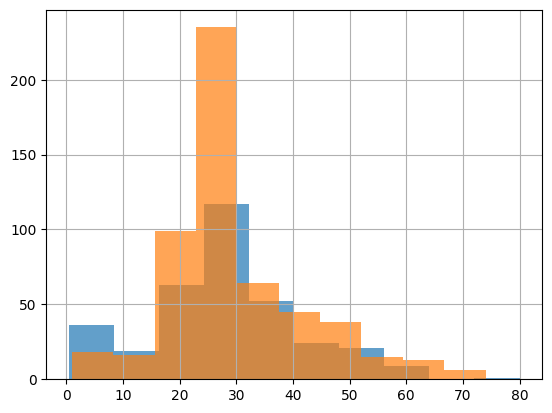

In [16]:
df[df["survived"]==1]["age"].dropna().hist(alpha=0.7)
df[df["survived"]==0]["age"].dropna().hist(alpha=0.7)


In [17]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
print(df.groupby("embarked")["survived"].mean())


embarked
C    0.553571
Q    0.389610
S    0.339009
Name: survived, dtype: float64


In [18]:
df["TicketClassSim"] = df["class"].astype(str).str[0]
print(df.groupby("TicketClassSim")["survived"].mean())


TicketClassSim
F    0.629630
S    0.472826
T    0.242363
Name: survived, dtype: float64


In [19]:
print(df["fare"].isna().sum())
print(df.groupby("class")["fare"].median())


0
class
First     60.2875
Second    14.2500
Third      8.0500
Name: fare, dtype: float64


C:\Users\Harsha vardhan\AppData\Local\Temp\ipykernel_14016\3398484547.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["fare"].median())
